<div style="background-color:#00CCCC"> 
<center>
    <h1 style="margin: auto; padding:30px;">Compte rendu de TP</h1>
</center>
</div>

### Librairies importées

In [62]:
# Librairies pour accèder au fichier
import os, sys

# Librairies pour manipuler les données images et calculées
import cv2
import numpy as np
import pandas as pd
from scipy.spatial import distance

# Librairies pour visualiser les résultats
import matplotlib.pyplot as plt
import webbrowser
import seaborn as sns

### Créer la fichier recensant toutes les références au images

In [ ]:
# Créer la liste des images de la base
# Entrée : répertoire contenant les images
# Sortie : création d'un fichier base10000_files.txt contenant la liste des images rangées dans l'ordre de lecture
def CreateFiles_base10000(path):
    files=[file for file in os.listdir(path) if not file.startswith('.')]
    with open("base10000_files.txt",'w+') as f:
        for file in files:
            f.write(file)
            f.write('\n')
    return os.getcwd()+"/base10000_files.txt"

### Calculer l'histogramme de niveau de gris

In [2]:
# Calculer l'histogramme en niveau de gris (défini en nombre de bins) d'une image
# Entrée : chemin, image et nombre de bins (16, 64, 256)  
# Sortie : histogramme en niveau de gris de 16, 64 ou 256
def ComputeGrayLevelHistogram(path,image,bins):
    image=path+image
    image=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    bins=bins
    hist=cv2.calcHist([image], [0],None, [bins], [0,256])
    hist=cv2.normalize(hist,hist)
    return hist

### Calculer l'histogramme de couleur

In [3]:
# Calculer l'histogramme en niveau de gris (défini en nombre de bins) d'une image
# Entrée : chemin, image et nombre de bins (6, 4, 2)  
# Sortie : histogramme de couleur de 6, 4 ou 2
def ComputeRGBHistogram (path,image,bins):
    image=path+image
    image=cv2.imread(image,cv2.IMREAD_COLOR)
    bins=[bins,bins,bins]
    hist=cv2.calcHist([image], [0,1,2],None, bins, [0,256,0,256,0,256])
    hist=cv2.normalize(hist,hist)
    return hist.flatten()

### Construire l'index

#### Afficher bar de progression (décoration)

In [4]:
# ======= Non utile =========
# Fonction pour créer une bar de progression
def progress_bar(count,total,size=100,sides="[]",full='#',empty='.',prefix=""):
    x = int(size*count/total)
    sys.stdout.write("\r" + prefix + sides[0] + full*x + empty*(size-x) + sides[1] + ' ' + str(count).rjust(len(str(total)),' ')+"/"+str(total))
    sys.stdout.flush()
    if count==total:
        sys.stdout.write("\n")

#### Indexation des images

In [5]:
# Calculer l'index d'histogramme des images
# Entrée : chemin, image et nombre de bins (16->16, 64->4, 256->1)  
# Sortie : histogramme en niveau de gris de 16, 64 ou 256
def IndexDataBase(path, index, methode, bins):
    indexName = os.getcwd() + "/Base10000." + methode + "_" + str(bins) + ".txt"
    index = os.getcwd() + "/" + index
    result = None
    i=0
    index = pd.read_csv(index,names=['BDD'])
    for key, image in listing.iterrows():
        if methode == "HistGREY" :
            descriptor = ComputeGrayLevelHistogram(path,image['BDD'],bins)
            df = pd.DataFrame(descriptor)
        elif methode == "HistRGB" :
            descriptor = ComputeRGBHistogram(path,image['BDD'],bins)
            df = pd.DataFrame(descriptor)
        else :
            descriptor = []
            sys.exit("La variable methode prend soit HistGREY soit HistRGB ")
        result = pd.concat([result,df.T],axis=0)
        i=i+1
        progress_bar(count=i,total=10000,prefix="working...")
    result.to_csv(indexName, header=None, index=None, sep=' ')
    return result

### Requêter par l'exemple sur le base de donnée

#### Calculer la distance euclidienne

In [8]:
# Calculer la distance euclidienne entre l'image requête et les images de la base de donnée
# Entrée : 
# - image : la référence de l'image
# - directoryImages : 
# - directoryFile : 
# - methode : 
# - baseFile : le fichier contenant les références des images
# - bins : nombre de bins
# Sortie : dataframe des images triées dans l'ordre croissant de la distance euclicienne
def QBE(image,path,bins,methode,index):
    indexName = os.getcwd() + "/Base10000." + methode + "_" + str(bins) + ".txt"
    listing = os.getcwd() + "/" + index
    if methode == "HistGREY": 
        a=ComputeGrayLevelHistogram(path, image,bins)
    elif methode == "HistRGB": 
        a=ComputeRGBHistogram(path,image,bins)
    else :
        sys.exit("La variable methode prend soit HistGREY soit HistRGB ")
    indexFile = pd.read_csv(indexName,header=None,sep=' ')
    listing = pd.read_csv(listing,names=['BDD'])
    indexFile['Score']=indexFile.apply(lambda x : distance.euclidean(a, x),axis=1)
    indexFile.insert(0,"Image",listing)
    indexFile.sort_values(by=['Score'],ascending=True,inplace=True)
    indexFile.reset_index(drop=True,inplace=True)
    return indexFile

#### Visualiser les résultats

In [ ]:
# Affiche les résultats de la requête avec l'image exemple en premier -> QBE (Query By Example)
# Entrée : chemin de la liste d'image 
# Sortie : un html avec la liste des images  
def VisualizeResult(dictImages,k=-1):
    # Ouvrir/créer un nouveau fichier html en mode écrase/remplace
    f = open('QBE.html', 'w')
    # constuire le code html qui ira dans le fichier QBE.html
    start = """<html><head><title>Clusters</title></head><body>"""
    body = ""
    i=0
    for key, image in dictImages.iterrows():
        body = body + f"""<img src="{directoryImages}{image['Image']}" width="100" title="{image['Image']}">"""
        i+=1
        if (i == k+1): break 
    end = """</body></html>"""
    html_template = "".join([start,body,end])
    # ecrire le code dans le fichier QBE.html
    f.write(html_template)
    # fermer le fichier
    f.close()
    # ouvrir la page dans le navigateur
    webbrowser.open('QBE.html',new=0,autoraise=True)

### Calcule courbe Précision / Rappel

#### Charger vérité terrain

In [17]:
# Charge la VT dans un dataframe
# Entrée : chemin où se trouve les fichiers de vérités terrains
# Sortie : dataframe de la vérité terrain 
def LoadVT(pathVT):
    VT_description = pd.read_csv(pathVT + 'VT_description.txt',header=None, names=['Class'])
    VT_files = pd.read_csv(pathVT + 'VT_files.txt',header=None,sep=' ')
    VT=VT_files
    VT.insert(0,"Class",VT_description['Class'])
    return VT

#### Récupèrer les élements de la classe

In [10]:
# Récupère le dataframe correspondant à la classe dans la VT
# Entrée : dataframe VT et le nom de la classe
# Sortie : dataframe de la classe + sa longueur
def GetClass (VT, nameClasse):
    df = VT.loc[VT['Class']==nameClasse].reset_index(drop=True).T
    df.rename(columns={0: 'Image'},inplace=True)
    df.drop(['Class'], axis=0, inplace=True)
    return df, len(df.axes[0])

#### Requêter pour chaque image de la classe

In [27]:
# Parcour chacune des images de la classe et calcule la requête sur la base
# Entrée : 
# - VT : dataframe de la vérité terrain
# - path : chemin de la base d'image
# - classe : dataframe de la classe
# - methode : méthode utilisée
# - bins : nombre de bins
# - index : nom du fichier index
# Sortie : 
# - dataframe la première colonne est l'image d'appel et les 9999 autres colonnes sont les résultats dans l'ordre croissant
def ComputeQBEByClasse(VT, db, classe, methode, bins, index):
    result = None
    i=0
    for key, image in classe.iterrows():
        qbe = QBE(image['Image'],db,bins,methode,index)
        result = pd.concat([result,qbe[['Image']].T],axis=0)
        i+=1
        progress_bar(count=i,total=100,prefix="")
    return result.reset_index(drop=True)

#### Compter le nombre d'image appartenant à la classe

In [12]:
# Compte le nombre d'image réponse appartenant à la classe
# Entrée : dataframe de la classe et le dataframe de réponse trié dans l'ordre croissant de similarité avec l'image requête
# Sortie : le nombre d'image rétournée appartenant à la classe
def CountNbResponseInClass(classe,responses):
    responses = responses['Image'].values.tolist()
    in_classe = classe[['Image']].isin(responses)
    count = in_classe[['Image']][in_classe['Image']==True].count()
    return in_classe, count['Image']

#### Calculer la précision et le rappel pour une classe

In [25]:
# Compte le nombre d'image réponse appartenant à la classe
# Entrée : dataframe de la classe et le dataframe de réponse trié dans l'ordre croissant de similarité avec l'image requête
# Sortie : le nombre d'image rétournée appartenant à la classe
def ComputeCurvePR(pathVT, db, classeName, methode, bins, index):
    
    # Charger VT
    VT = LoadVT(pathVT)
    print("Récupération de la VT : DONE !")
    
    # Recupérer les classes de la vérité terrain
    classe, classeLen = GetClass(VT, classeName)
    print("Récupération de la classe : DONE !")
    
    # Requêter pour chaque images de la classe
    print("QBE computing...")
    responses = ComputeQBEByClasse(VT, db, classe, methode, bins, index)
    print("Récupération réponses pour chaque images de la classe : DONE !")
    
    # calculer la courbe précision et rappel pour la calcul
    precision = []
    rappel = []
    print("CURVE AR computing...")
    for i in range(1,classeLen):
        for j in range(1,responses.shape[1]):
            responses_knn=pd.Series(responses.iloc[i,:j],name='Image')
            responses_knn=responses_knn.to_frame()
            _,cnt=CountNbResponseInClass(classe,responses_knn)
            precision.append(round(cnt/responses_knn.shape[0],5))
            rappel.append(round(cnt/classeLen,5))
            progress_bar(count=j, total=10000, prefix=str(i+1)+"/"+ str(classeLen) + " ")
    print("Calcul de la courbe précision / rappel pour la classe : DONE !")
    
    # generer un fichier en sortie
    data = {'Accurancy':precision,'Recall':rappel}
    couple = pd.DataFrame(data)
    courbePR = couple.groupby('Recall').agg({'Accurancy': 'mean'}).reset_index(drop=False)
    nameResultFile = "/" + classeName + "_PR_" + methode + "_" + str(bins)
    points = os.getcwd() + nameResultFile
    courbePR.to_csv(points, header=None, index=None, sep=' ')
    print("Export des données : DONE !")
    
    return courbePR

In [109]:
# Test ComputeCurvePR
cheminVT = "D:/FORMATION/Formation_CNAM/NFE205_BDD_Multimedia/projet/Base10000/Base10000/"
cheminBaseImage = "D:/FORMATION/Formation_CNAM/NFE205_BDD_Multimedia/projet/Base10000/Base10000/images/"
nomClasse = "Fabulous_Fruit"
methode = "HistRGB"
bins = 6
nomIndex = "base10000_files.txt"
result = ComputeCurvePR(cheminVT, cheminBaseImage, nomClasse, methode, bins, nomIndex)

Récupération de la VT : DONE !
Récupération de la classe : DONE !
QBE computing...
[####################################################################################################] 100/100
Récupération réponses pour chaque images de la classe : DONE !
CURVE AR computing...
100/100 [###################################################################################################.]  9999/10000Calcul de la courbe précision / rappel pour la classe : DONE !
Export des données : DONE !


### Visualisation des résultats

#### Visualisation comparatif descripteur Grey

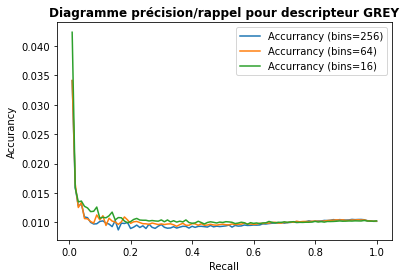

In [92]:
PR_HistGREY_256 = pd.read_csv('./result/Fabulous_Fruit_PR_HistGREY_256.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistGREY_64 = pd.read_csv('./result/Fabulous_Fruit_PR_HistGREY_64.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistGREY_16 = pd.read_csv('./result/Fabulous_Fruit_PR_HistGREY_16.txt',header=None,sep=' ',names=['Recall','Accurancy'])
sns.lineplot(data=PR_HistGREY_256,x='Recall',y='Accurancy',label='Accurrancy (bins=256)')
sns.lineplot(data=PR_HistGREY_64,x='Recall',y='Accurancy',label='Accurrancy (bins=64)')
sns.lineplot(data=PR_HistGREY_16,x='Recall',y='Accurancy',label='Accurrancy (bins=16)')
plt.title('Diagramme précision/rappel pour descripteur GREY', fontweight ='bold')
plt.xlabel('Recall')
plt.ylabel('Accurancy')
plt.savefig('./result/HistGREY.png')

#### Visualisation comparatif descripteur RGB

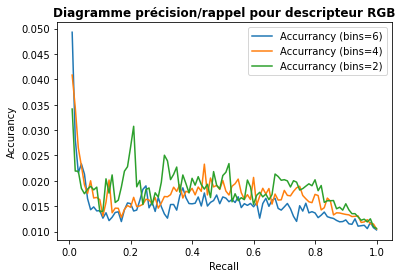

In [110]:
PR_HistRGB_6 = pd.read_csv('./result/Fabulous_Fruit_PR_HistRGB_6.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistRGB_4 = pd.read_csv('./result/Fabulous_Fruit_PR_HistRGB_4.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistRGB_2 = pd.read_csv('./result/Fabulous_Fruit_PR_HistRGB_2.txt',header=None,sep=' ',names=['Recall','Accurancy'])
sns.lineplot(data=PR_HistRGB_6,x='Recall',y='Accurancy',label='Accurrancy (bins=6)')
sns.lineplot(data=PR_HistRGB_4,x='Recall',y='Accurancy',label='Accurrancy (bins=4)')
sns.lineplot(data=PR_HistRGB_2,x='Recall',y='Accurancy',label='Accurrancy (bins=2)')
plt.title('Diagramme précision/rappel pour descripteur RGB', fontweight ='bold')
plt.xlabel('Recall')
plt.ylabel('Accurancy')
plt.savefig('./result/HistRGB.png')

#### Visualisation comparatif descripteur RGB vs GREY

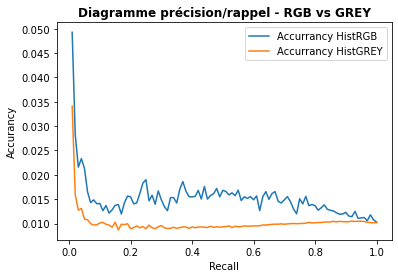

In [98]:
PR_HistRGB = pd.read_csv('./result/Fabulous_Fruit_PR_HistRGB_6.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistGREY = pd.read_csv('./result/Fabulous_Fruit_PR_HistGREY_256.txt',header=None,sep=' ',names=['Recall','Accurancy'])
sns.lineplot(data=PR_HistRGB,x='Recall',y='Accurancy',label='Accurrancy HistRGB')
sns.lineplot(data=PR_HistGREY,x='Recall',y='Accurancy',label='Accurrancy HistGREY')
plt.title('Diagramme précision/rappel - RGB vs GREY', fontweight ='bold')
plt.xlabel('Recall')
plt.ylabel('Accurancy')
plt.savefig('./result/HistRGBvsGREY.png')

#### Visualisation comparatif descripteur RGB vs RGB VT

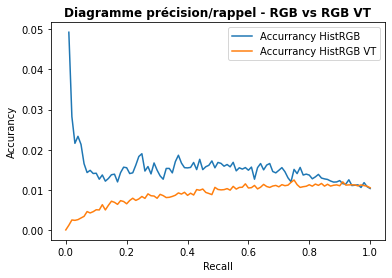

In [108]:
PR_HistRGB = pd.read_csv('./result/Fabulous_Fruit_PR_HistRGB_6.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistRGB_VT = pd.read_csv('./result/Fabulous_Fruit_PR_HistRGB_6_VT_2.txt',header=None,sep=' ',names=['Recall','Accurancy'])
sns.lineplot(data=PR_HistRGB,x='Recall',y='Accurancy',label='Accurrancy HistRGB')
sns.lineplot(data=PR_HistRGB_VT,x='Recall',y='Accurancy',label='Accurrancy HistRGB VT')
plt.title('Diagramme précision/rappel - RGB vs RGB VT', fontweight ='bold')
plt.xlabel('Recall')
plt.ylabel('Accurancy')
plt.savefig('./result/HistRGBvsRGBVT.png')

#### Visualisation comparatif descripteur GREY vs GREY VT

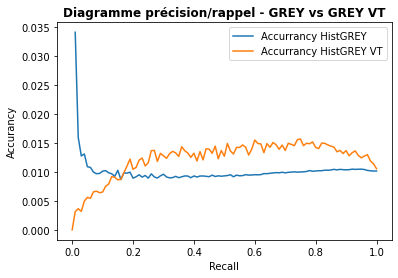

In [105]:
PR_HistGREY = pd.read_csv('./result/Fabulous_Fruit_PR_HistGREY_256.txt',header=None,sep=' ',names=['Recall','Accurancy'])
PR_HistGREY_VT = pd.read_csv('./result/Fabulous_Fruit_PR_HistGREY_256_VT.txt',header=None,sep=' ',names=['Recall','Accurancy'])
sns.lineplot(data=PR_HistGREY,x='Recall',y='Accurancy',label='Accurrancy HistGREY')
sns.lineplot(data=PR_HistGREY_VT,x='Recall',y='Accurancy',label='Accurrancy HistGREY VT')
plt.title('Diagramme précision/rappel - GREY vs GREY VT', fontweight ='bold')
plt.xlabel('Recall')
plt.ylabel('Accurancy')
plt.savefig('./result/HistGREYvsGREYVT.png')